# N-HiTS

In [17]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS


In [18]:
# LOAD + PREPROCESS (sesuai aturan kamu)
df = pd.read_csv("electricity_daily_total.csv")

df["ds"] = pd.to_datetime(df["ds"])
df["y"] = pd.to_numeric(df["y"], errors="coerce")

df = df.sort_values("ds").drop_duplicates()
df = df.fillna(method="ffill").fillna(method="bfill")

df["unique_id"] = "series_1"


In [19]:
# SPLIT 70/10/20
n = len(df)

train_end = int(n * 0.7)
val_end   = int(n * 0.8)

train_full = df.iloc[:val_end].copy()   # train + val
test_df    = df.iloc[val_end:].copy()


In [20]:
# MODEL (pakai horizon = test size biar panjang sama)
horizon = len(test_df)

model = NHITS(
    h=horizon,
    input_size=30,
    max_steps=200,
    early_stop_patience_steps=30
)

nf = NeuralForecast(models=[model], freq="D")


Seed set to 1


In [21]:
# TRAIN (no error val_size)
nf.fit(
    df=train_full,
    val_size=horizon
)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.7 M  | train
-------------------------------------------------------
2.7 M     Trainable params
0         Non-trainable params
2.7 M     Total params
10.820    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=200` reached.


In [22]:
# PREDICT (panjang pasti sama)
forecast = nf.predict()

y_pred = forecast["NHITS"].values
y_true = test_df["y"].values
ds_test = test_df["ds"]

print("Length:", len(y_true), len(y_pred))


Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Length: 293 293


In [23]:
# METRICS (tidak akan error)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

smape = np.mean(
    2 * np.abs(y_pred - y_true) /
    (np.abs(y_true) + np.abs(y_pred))
) * 100

naive = np.mean(np.abs(np.diff(y_true)))
mase = mae / naive

print("RMSE:", rmse)
print("MAE :", mae)
print("sMAPE:", smape)
print("MASE :", mase)


RMSE: 21838.019682821287
MAE : 16778.765236292835
sMAPE: 7.166157856793834
MASE : 2.7873482551399413


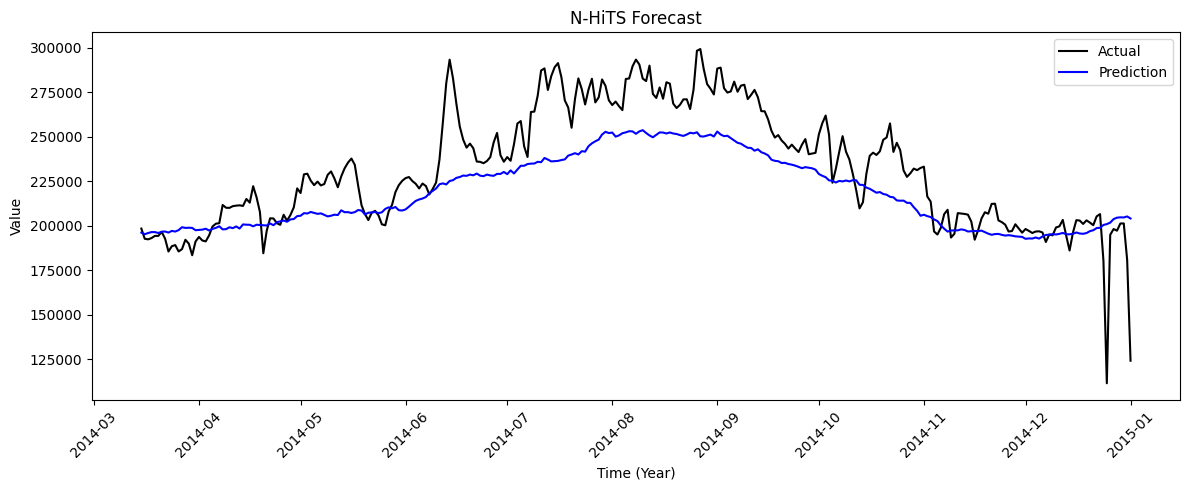

In [25]:
ds_test = test_df["ds"].iloc[:len(y_true)]

plt.figure(figsize=(12,5))

plt.plot(ds_test, y_true, label="Actual", color="black")
plt.plot(ds_test, y_pred, label="Prediction", color="blue")

plt.title("N-HiTS Forecast")
plt.xlabel("Time (Year)")
plt.ylabel("Value")

plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()